#Comparative Assessment of Machine Learning Models for Chronic Disease Prediction: Performance Optimization and Clinical Implications


## Introduction

Machine learning (ML) has transformed various industries, and its applications in healthcare have shown tremendous promise in the past few years. Several basic reasons contributed to the advancement of machine learning in healthcare. First, the rising frequency of chronic diseases has led to a need for precise and scalable diagnostic technologies (Kehinde, 2025). Current machine learning uses include disease diagnosis, patient monitoring, and medication discovery.

Diabetes mellitus, commonly referred to as diabetes, is a chronic disease marked by consistently elevated blood glucose levels brought on by either insufficient insulin production or the body's inability to use the insulin that is generate (Hossain and Al-Mamun and Islam, 2024). One of the biggest worldwide health issues of the twenty-first century is diabetes mellitus. According to the World Health Organisation(WHO), over the past three decades, the prevalence of diabetes has been continuously rising, with 422 million people worldwide living with the disease [3]. For prompt medical intervention and to avoid impacts from misdiagnosed or inadequately controlled diabetes, early diagnosis is essential (Davies et al., 2022).

Because of their capacity to analyse vast amounts of patient data and produce highly accurate predictions, artificial intelligence (AI) and machine learning (ML) are becoming more and more popular in the healthcare industry. It can predict the risk of diabetes early and with greater accuracy (Dixon et al., 2024).

In this project, I use the well-known "Pima Indians Diabetes Dataset" to apply machine learning to the task of diabetes prediction. This dataset incudes 768 female patients with Pima Indian ancestry who are at least 21 years old are included in this dataset. Information including blood pressure, BMI, insulin, glucose level, and if the patient has diabetes are all included in each record. Using the Pima Indians Diabetes Dataset, the research seeks to create and evaluate multiple machine learning models for diabetes prediction.  This study aims to determine the best method for early diabetes detection by assessing the performance of various classification algorithms, fine-tuning their parameters, and examining feature importance.

The practical importance of diabetes prevention and the expanding potential for AI-powered diagnostic improvement are the main reasons I chose this topic. My project adopts a more thorough strategy by:

-Comparing several different algorithms: Random Forest, Support Vector Machines, and Logistic Regression

-Conducting exploratory data analysis (EDA) and using ROC curves and confusion matrices to visualise model performance

-Examining the significance of features to comprehend important predictions







In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Display plots inline
%matplotlib inline



## Methods

#### Dataset Description

This project is based on the "Pima Indians Diabetes Dataset" available on [Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database). Each record includes nine features for input, including:

1. Number of pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin level
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome

**Outcome** is a binary variable, with '1' indicating the presence of diabetes and '0' indicating no diabetes.


#### Problem Description
This study aims to accurately predict whether a patient has diabetes based on diagnostic parameters. This is structured as a **binary classification problem**, which is appropriate for supervised machine learning techniques.


#### Initial Analysis and Data Cleaning

I performed exploratory data analysis and addressed important data quality concerns prior to creating models:

- **In nature problematic zero values** were substituted with `NaN` for features such as Blood Pressure, Skin Thickness, Insulin, BMI, and Glucose.
- To maintain data integrity, missing values were then **imputed with the median**.
-Reviewed and eliminated any records that were **duplicates**.


#### Data Preprocessing

To guarantee the best model performance, the dataset has to go through a number of preprocessing steps:

- **To have a mean of 0 and a standard deviation of 1, all numerical features were **standardised using `StandardScaler`**. This phase is important since many machine learning algorithms work better with standardised input. e.g., age in years vs. BMI
- To guarantee fair representation of both classes, the data was **split into training (80%) and test (20%) sets** using `train_test_split()` with `stratify=y`.
-  **Missed Value Treatment**: Zero values in the Glucose, BloodPressure, SkinThickness, Insulin, and BMI columns were **handled as missing values**.

#### Use of Machine Learning Algorithms

Three classification algorithms were picked and assessed:

1. **Logistic Regression**.  
  A frequently used linear classifier with excellent baseline performance that predicts the probability of an outcome based on one or more input variables.


2. **The Random Forest Classifier**  
  A collective approach notable for its resilience, ability to handle nonlinear relationships, and feature importance analysis [6].

3.  **SVM (Support Vector Machine)**  
  Suitable for high-dimensional data and effective when the decision boundary is non-linear [7].


#### Hyperparameter Tuning

To increase model performance and demonstrate depth, I used **GridSearchCV**-based tuning for Random Forest and SVM

- **Random Forest**: Modified 'n_estimators','max_depth', and'min_samples_split'.

- **SVM**: tuned 'C', 'kernel', and 'gamma'.


#### Evaluation Metrics

Models were tested using different performance metrics:

- **Accuracy**: Total accuracy of the prediction
- **Precision / Recall / F1-score**: To evaluate each class's performance
- **AUC-ROC**: The model's capacity to discriminate across classes is indicated by the area under the Receiver Operating Characteristic curve (Nahm, 2022).
- **Confusion Matrix**: A graphic representation of forecasted and actual results
- **Feature Importance**: Key determinants of diabetes were interpreted using analysis from the Random Forest


In [ ]:
# Preliminary Exploration
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values Per Column:")
print(df.isnull().sum())
print(f"\nNumber of Duplicate Rows: {df.duplicated().sum()}")
print("\nOutcome Variable Distribution:")
print(df["Outcome"].value_counts())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB
None

Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  763.000000     733.000000     541.000000  394.000000   
mean      3.845052  121.686763      72.405184  

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np  # Add import for numpy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
...

# Load the dataset
try:
    df = pd.read_csv("diabetes.csv")  # Ensure this file exists in the same directory
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'diabetes.csv' not found. Please check the file location.")
    exit()

print("\nFirst 5 rows of the dataset:")
print(df.head())

# Clean missing values
columns_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)
print("\nMissing Values After Replacing Zeros:")
print(df.isnull().sum())

# Standardize features
df_scaled = df.copy()
scaler = StandardScaler()
features = df_scaled.drop(columns=['Outcome'])
df_scaled[features.columns] = scaler.fit_transform(features)

# Train-test split
X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)



Dataset loaded successfully!

First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing Values After Replacing Zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedig

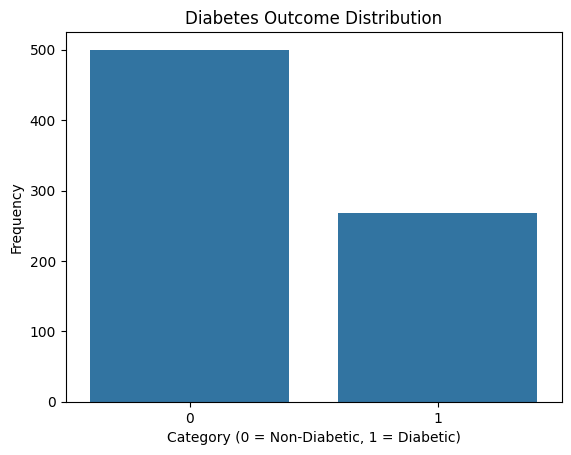

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes.csv')

sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Distribution')
plt.xlabel('Category (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Frequency')
plt.show()

##  Exploratory Data Analysis (EDA)

Before modelling, we illustrate feature correlations, class distribution, and patterns in this section.

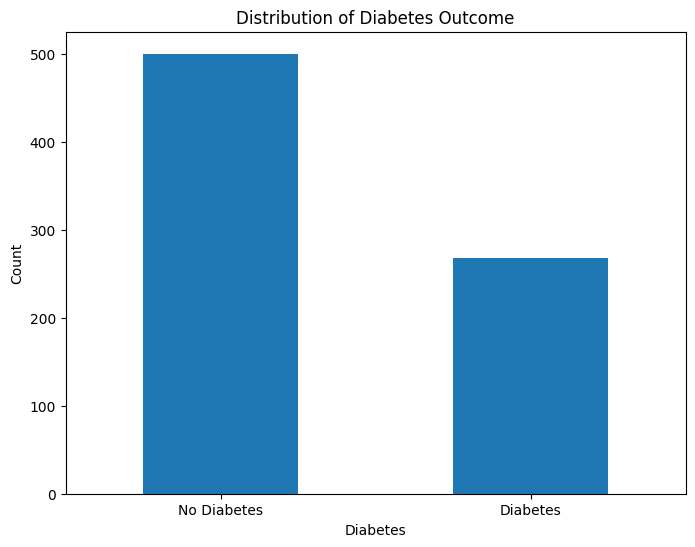

In [ ]:
plt.figure(figsize=(8, 6))
df['Outcome'].value_counts().plot(kind='bar')
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'], rotation=0)
plt.show()


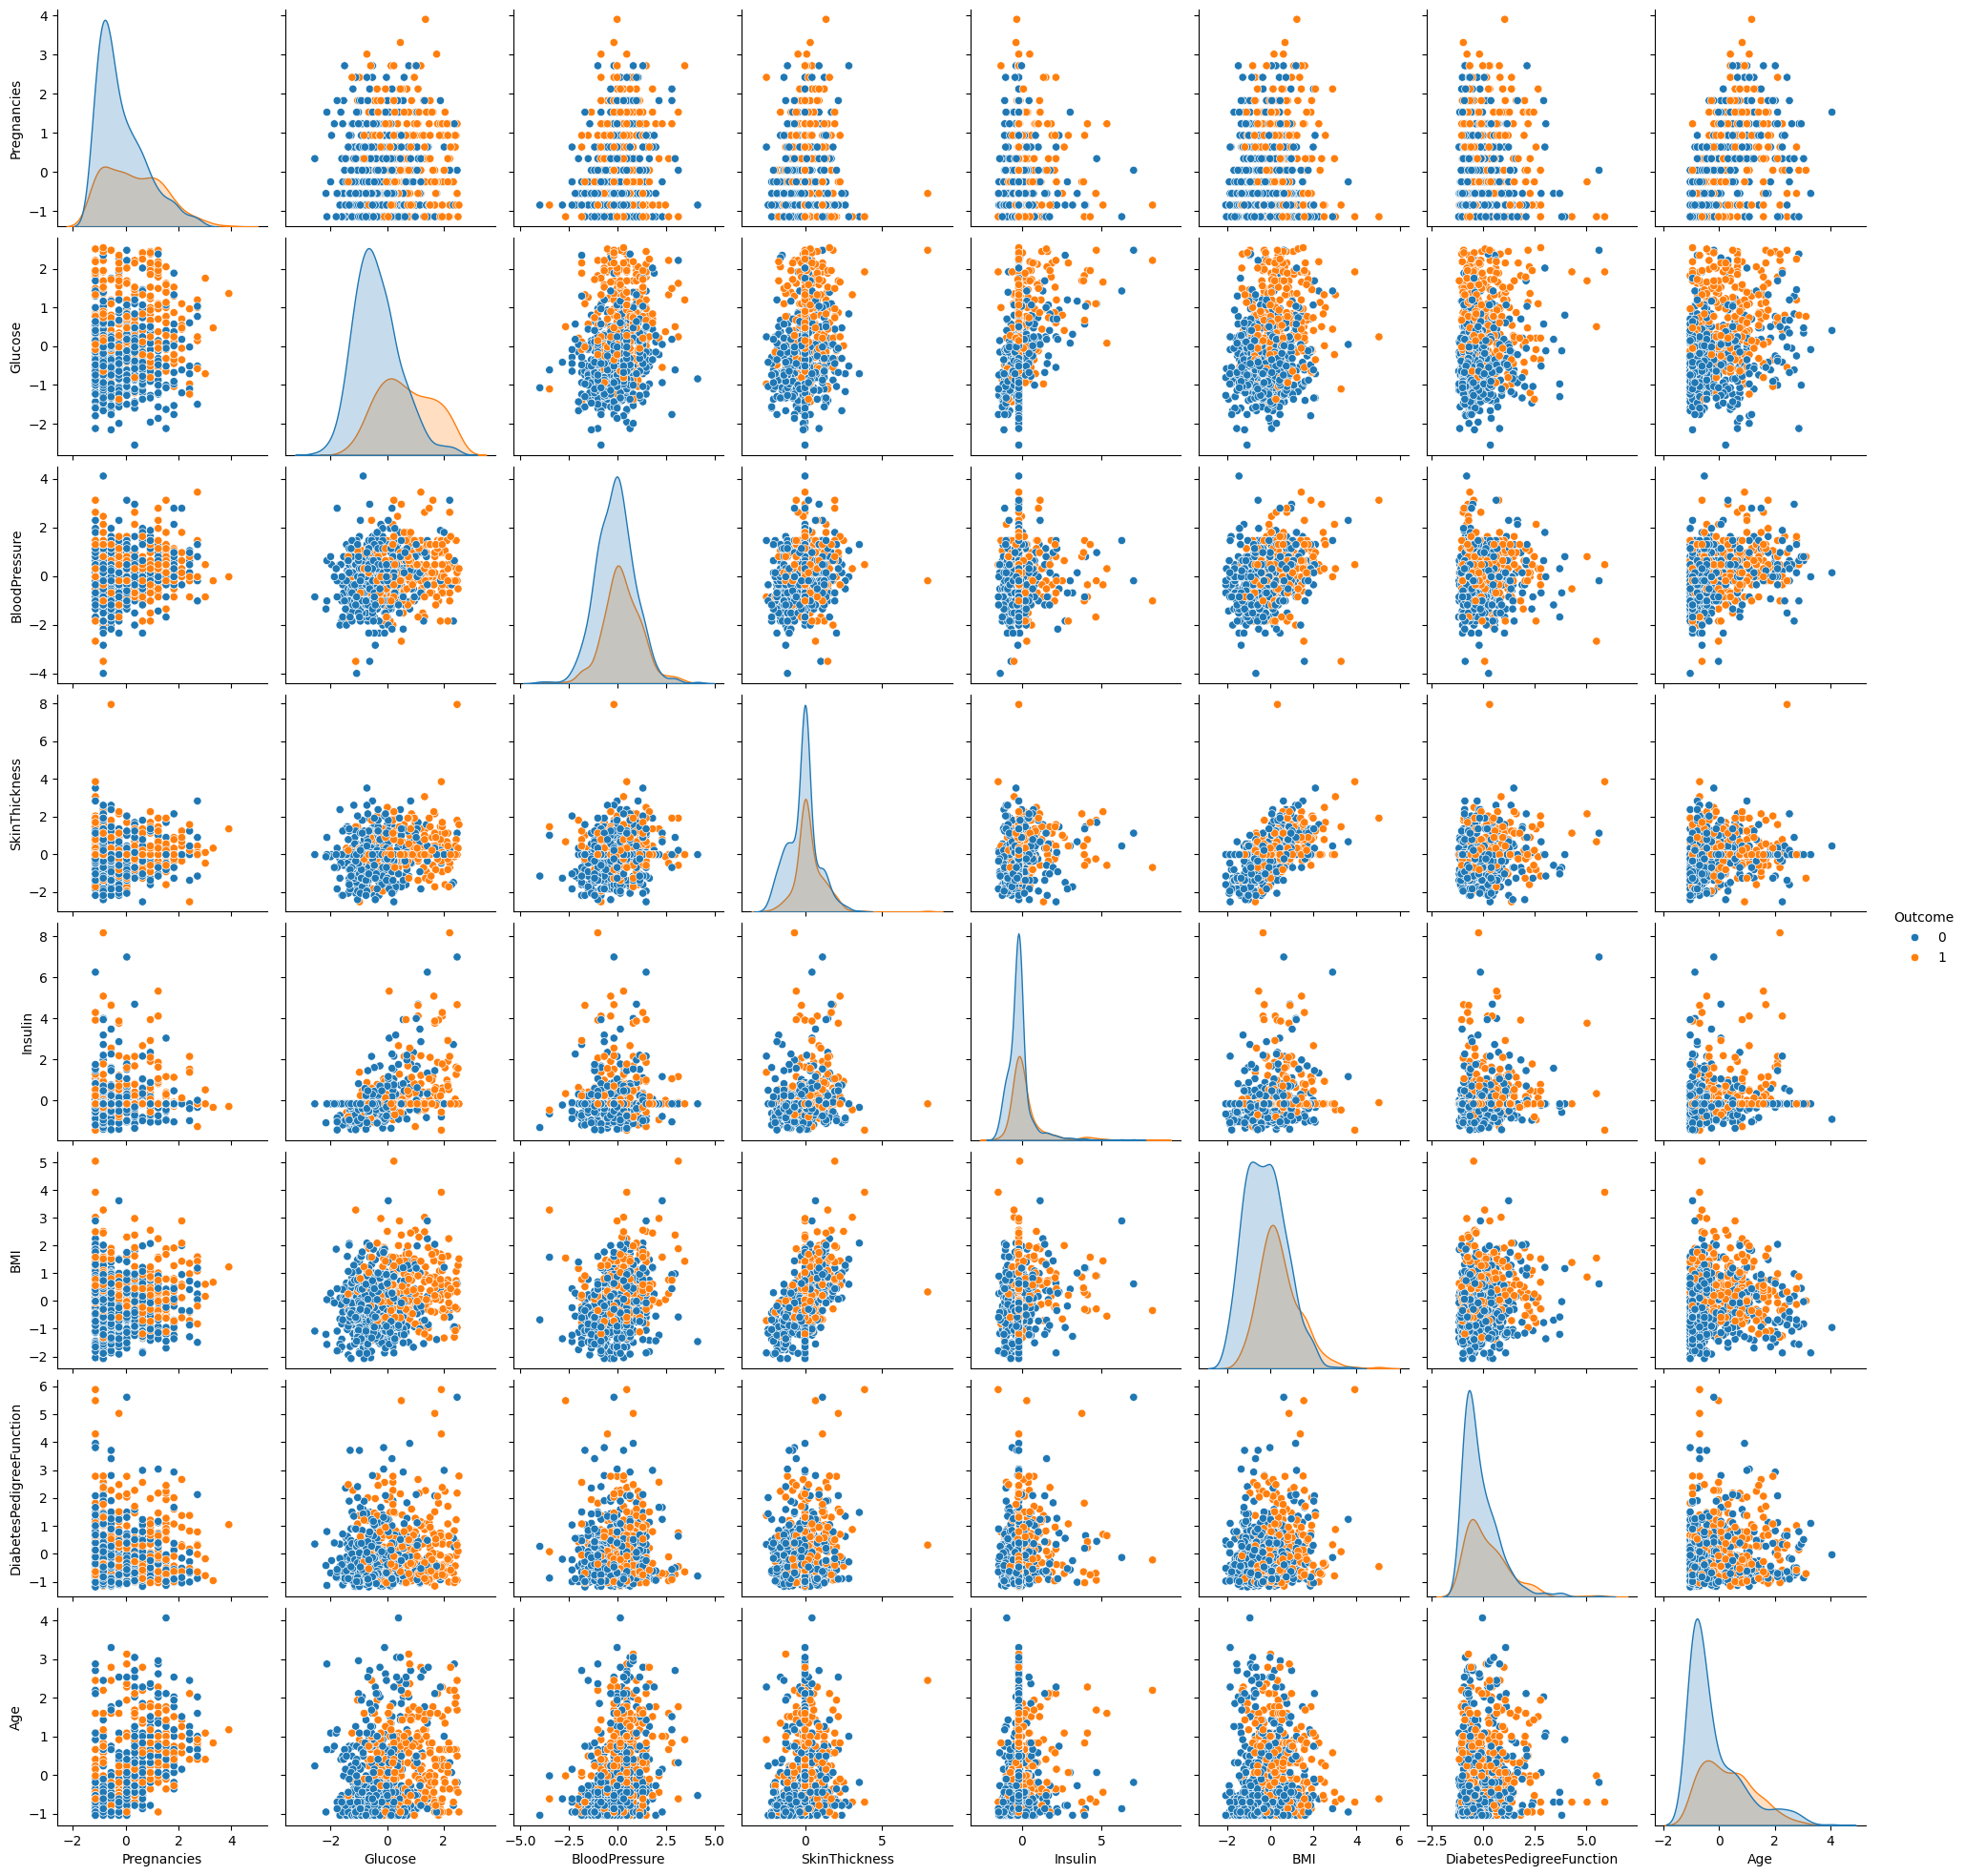

In [ ]:

#Pairplot for analysing feature relations
sns.pairplot(df_scaled, hue='Outcome')
plt.show()


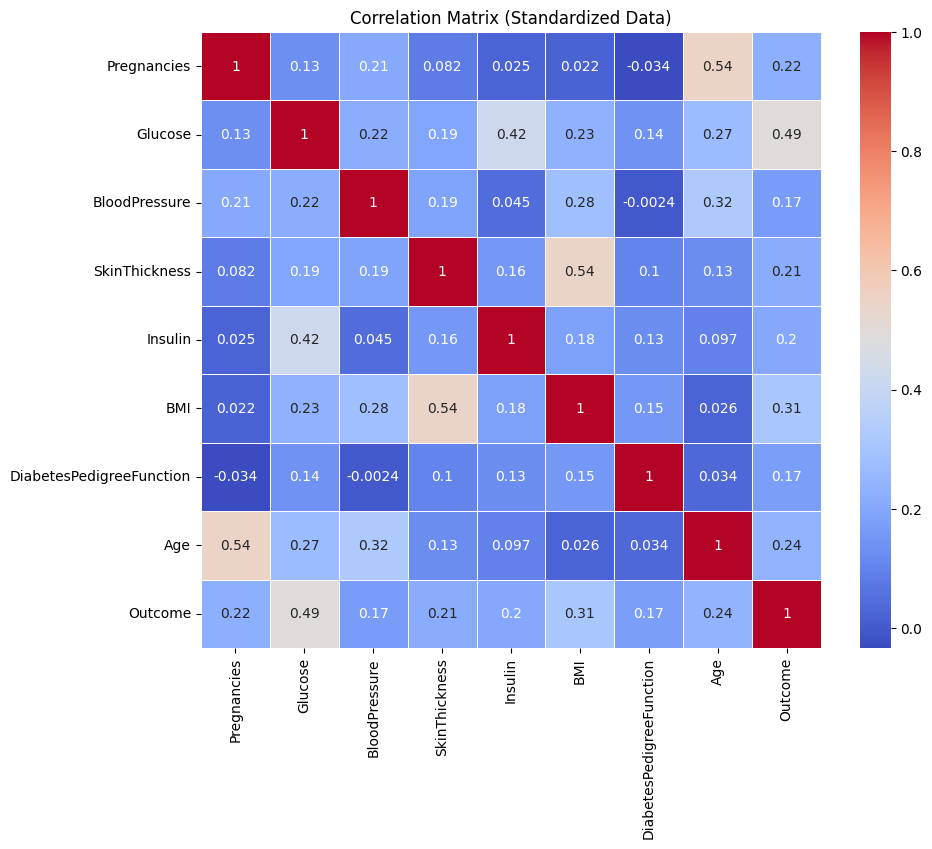

In [ ]:
# Correlation matrix of features
plt.figure(figsize=(10, 8))
sns.heatmap(df_scaled.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix (Standardized Data)")
plt.show()

### Results

In this classification problem, **Outcome** is the target variable, where:
Patients with diabetes are indicated by - {1`.
A patient with - {0` is not diabetic.


On the basis of diagnostic features, the models seek to forecast this binary result.

---

#### Model Performance Comparison
| Model                | Accuracy | AUC-ROC | Precision (1) | Recall (1) | F1-score (1) |
|---------------------|----------|---------|----------------|------------|--------------|
| Logistic Regression | 0.7013   | 0.8128  | 0.59           | 0.50       | 0.54         |
| Random Forest       | 0.7792   | 0.8191  | 0.73           | 0.59       | 0.65         |
| SVM (RBF Kernel)    | 0.7338   | 0.7963  | 0.64           | 0.54       | 0.59         |

**Notice:** The diabetic (class 1) group is represented by values in brackets.

---

- Although **Logistic Regression** showed a great AUC (0.81) and a reasonable accuracy (70%) for diabetic cases, it had a **low recall (0.50)**, which means it omitted a lot of true positives.

- The **best AUC-ROC (0.8191)** and **the greatest overall accuracy (77.9%)** were achieved by **Random Forest**.  For both classes, it showed the optimal balance between recall and precision.  Stronger true positive classification was displayed in its confusion matrix.

- With an accuracy of **73.4%** and an AUC of **0.7963**, **SVM** fared somewhat better than Logistic Regression, but still weaker than Random Forest.

---

#### Confusion Matrices

| Model                | TN | FP | FN | TP |
|---------------------|----|----|----|----|
| Logistic Regression | 81 | 19 | 27 | 27 |
| Random Forest       | 88 | 12 | 22 | 32 |
| SVM                 | 84 | 16 | 25 | 29 |


- While Logistic Regression produced the most false negatives (FN = 27), Random Forest** properly diagnosed more diabetic individuals (TP = 32).

---

#### Graphical Interpretation

- Random Forest has the best True Positive Rate at different levels, determined by **ROC Curves**.
- Errors in classification among models were vividly visualised by **Confusion Matrices** (heatmaps).
- **Feature Importance Plot** from Random Forest revealed that the best predictors of diabetes were **Glucose**, **BMI**, and **Age**.

---

### Model Tuning & Exploration

The Random Forest and SVM models' optimal hyperparameters were found using **GridSearchCV** in conjunction with 5-fold cross-validation to enhance model performance.

####  Random Forest Tuning

The hyperparameter grid that was utilised was as follows:

- `n_estimators`: [100, 150, 200]
- `max_depth`: [None, 5, 10, 15]
- `min_samples_split`: [2, 5, 10]

**Optimal parameters discovered**:
```python
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}



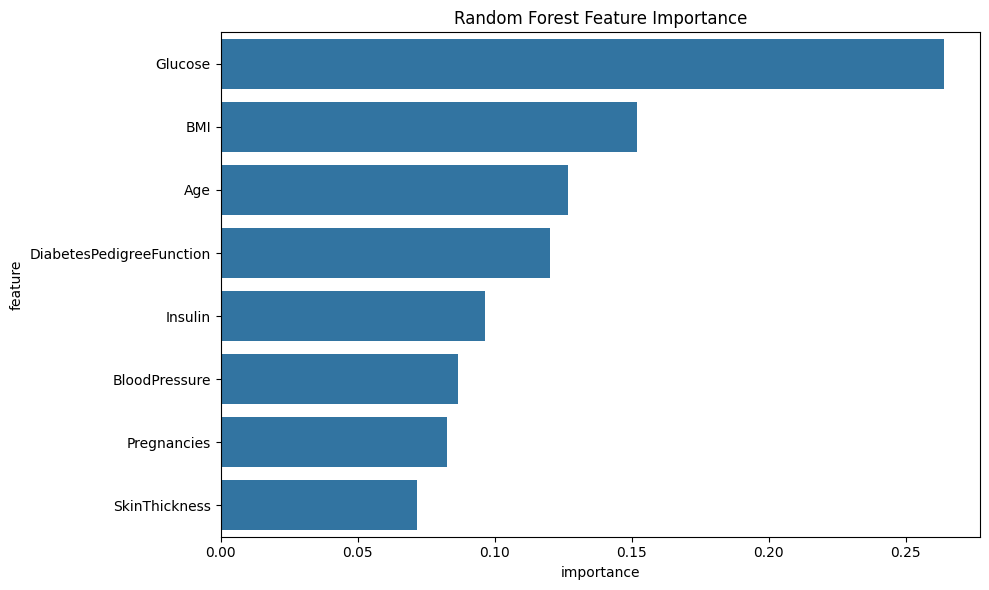

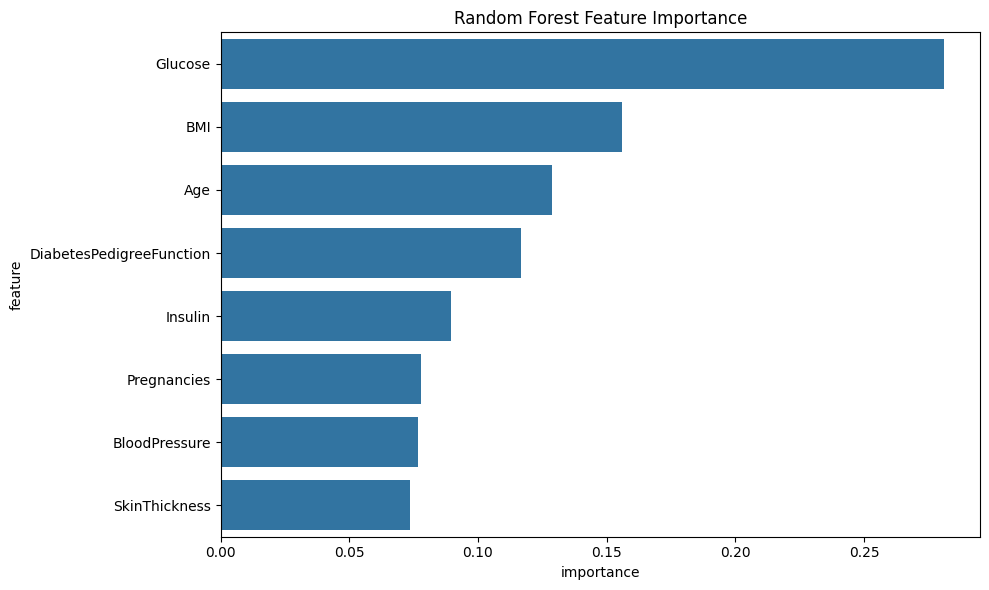

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier here
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

df = pd.read_csv('diabetes.csv')

# Handling missing or zero values in key columns
columns_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

# Standardize Features
scaler = StandardScaler()
features = df.drop(columns=['Outcome'])
df_scaled = df.copy()
df_scaled[features.columns] = scaler.fit_transform(features)

# Train-test split
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier here
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

df = pd.read_csv('diabetes.csv')

# Handling missing or zero values in key columns
columns_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

# Standardize Features
scaler = StandardScaler()
features = df.drop(columns=['Outcome'])
df_scaled = df.copy()
df_scaled[features.columns] = scaler.fit_transform(features)

# Train-test split
X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
importances = rf.feature_importances_
rf_importance = pd.DataFrame({'feature': X.columns, 'importance': importances})

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=rf_importance.sort_values(by='importance', ascending=False))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
importances = rf.feature_importances_
rf_importance = pd.DataFrame({'feature': X.columns, 'importance': importances})

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=rf_importance.sort_values(by='importance', ascending=False))
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

columns_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)
print("\nMissing Values After Replacing Zeros:")
print(df.isnull().sum())

# Fill missing values with median
df.fillna(df.median(), inplace=True)
print("\nMissing Values After Filling:")
print(df.isnull().sum())

# Standardize features (after handling missing values)
df_scaled = df.copy()
scaler = StandardScaler()
features = df_scaled.drop(columns=['Outcome'])
df_scaled[features.columns] = scaler.fit_transform(features)

# Train-test split (using the imputed and scaled data)
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

columns_to_replace = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[columns_to_replace] = df[columns_to_replace].replace(0, np.nan)
print("\nMissing Values After Replacing Zeros:")
print(df.isnull().sum())

# Fill missing values with median
df.fillna(df.median(), inplace=True)
print("\nMissing Values After Filling:")
print(df.isnull().sum())

# Standardize features (after handling missing values)
df_scaled = df.copy()
scaler = StandardScaler()
features = df_scaled.drop(columns=['Outcome'])
df_scaled[features.columns] = scaler.fit_transform(features)

# Train-test split (using the imputed and scaled data)
X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Display plots inline
%matplotlib inline

# Train models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True)
}

# Evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
%matplotlib inline

# Train models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True)
}

# Evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))



Missing Values After Replacing Zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing Values After Filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing Values After Replacing Zeros:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing Values After Filling:
Pregnancies

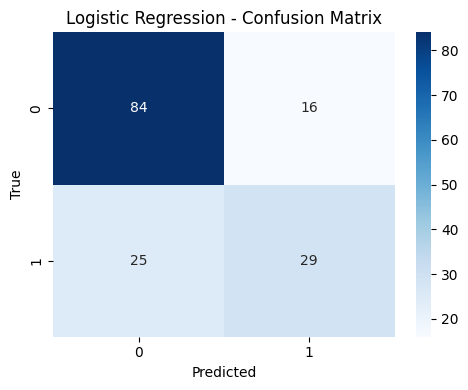

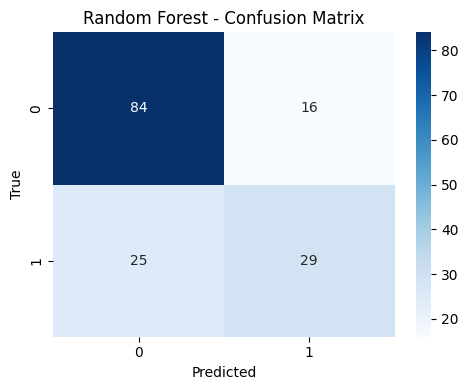

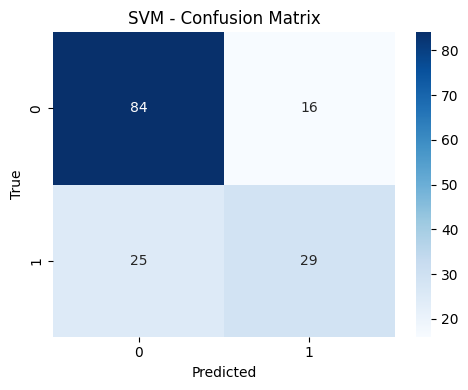

In [ ]:
 for name, model in models.items():
    ...
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

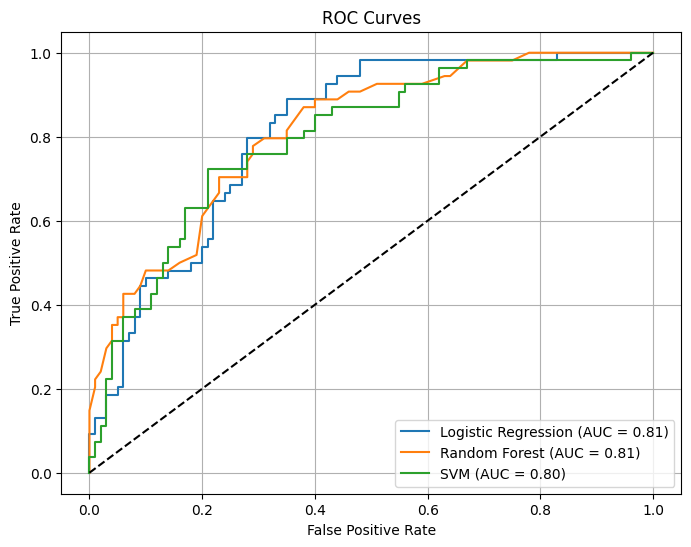

In [ ]:
# ROC Curve plot
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()


### Conclusion

The goal of this project was to examine how supervised machine learning methods might be used to forecast diabetes from patient diagnostic data. Several models were trained, assessed, and contrasted with both default and adjusted configurations using the Pima Indians Diabetes Dataset.

The findings demonstrated that:
- **Random Forest** outperformed both Support Vector Machine and Logistic Regression, achieving the greatest performance in general with a precision of **77.9%** and an AUC-ROC of **0.8191**.
- Despite being quick and easy to understand, **Logistic Regression** has problems with recall (50%) on diabetic cases, which is crucial in clinical settings.

Confusion matrices and ROC curves provided additional evidence that Random Forest was superior at detecting patients with and without diabetes.

Model settings were optimised through hyperparameter tuning using GridSearchCV, especially for Random Forest and SVM, highlighting the usefulness of model refining in real-world applications.

In summary, early diabetes prediction can be successfully supported by machine learning. Even if the dataset's results are encouraging, more testing on bigger and more varied datasets is advised prior to practical use. The research project effectively illustrates how AI may improve health risk prediction through data-driven analysis, which is consistent with the primary goal of utilising modern resources to improve healthcare outcomes.


##  References

1. Olalekan Kehinde, A. (n.d.) *Machine Learning in Predictive Modelling: Addressing Chronic Disease Management through Optimized Healthcare Processes*.

2. Hossain, M.J., Al-Mamun, M. and Islam, M.R. (2024) 'Diabetes mellitus, the fastest growing global public health concern: Early detection should be focused', *Health Science Reports*, 7(3), p.e2004.

3. World Health Organization (WHO) (2024) *Diabetes*. [online] Available at: https://www.who.int/en/health-topics/noncommunicable-diseases/diabetes/ [Accessed 29 Mar. 2025].

4. Davies, M.J., Aroda, V.R., Collins, B.S., Gabbay, R.A., Green, J., Maruthur, N.M., Rosas, S.E., Del Prato, S., Mathieu, C., Mingrone, G. and Rossing, P. (2022) 'Management of hyperglycaemia in type 2 diabetes, 2022', *Diabetologia*, 65(12), pp.1925-1966.

5. Dixon, D., Sattar, H., Moros, N., Kesireddy, S.R., Ahsan, H., Lakkimsetti, M., Fatima, M., Doshi, D., Sadhu, K., Hassan, M.J. and Dixon, D. (2024) 'Unveiling the influence of AI predictive analytics on patient outcomes: a comprehensive narrative review', *Cureus*, 16(5).

6. Svetnik, V., Liaw, A., Tong, C., Culberson, J.C., Sheridan, R.P. and Feuston, B.P. (2003) 'Random forest: a classification and regression tool for compound classification and QSAR modeling', *Journal of Chemical Information and Computer Sciences*, 43(6), pp.1947-1958.

7. Saini, A. (2021) *Support Vector Machines (SVM): A Complete Guide for Beginners*. [online] Analytics Vidhya. Available at: https://www.analyticsvidhya.com/blog/2021/10/support-vector-machinessvm-a-complete-guide-for-beginners/ [Accessed 29 Mar. 2025].

8. Nahm, F.S. (2022) 'Receiver operating characteristic curve: overview and practical use for clinicians', *Korean Journal of Anesthesiology*, 75(1), pp.25-36.
